# Smart Traffic Management System

## Exploratory Data Analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [17]:
DATA_PATH = Path("../data/processed/traffic_2025.csv")

df = pd.read_csv(
    DATA_PATH,
    nrows=10_000
)

print(df.shape)

(10000, 103)


In [18]:
traffic_columns = [
    col for col in df.columns
    if col.startswith("V") and col[1:].isdigit()
]

traffic_columns = sorted(
    traffic_columns,
    key=lambda x: int(x[1:])
)

print(len(traffic_columns))

96


## How does traffic vary across the 96 intervals?

In [19]:
interval_mean = df[traffic_columns].mean()

interval_mean.head()

V00    3.1192
V01    2.7293
V02    2.4578
V03    2.2024
V04    1.9577
dtype: float64

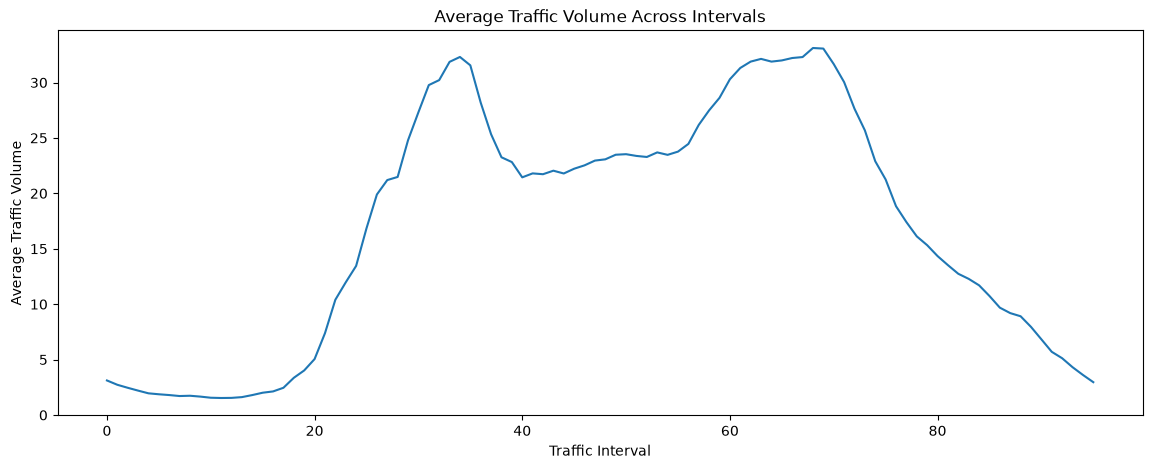

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    range(len(interval_mean)),
    interval_mean.values
)

plt.xlabel("Traffic Interval")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume Across Intervals")

plt.show()

## Which intervals are busiest?

In [21]:
top_intervals = (
    interval_mean
    .sort_values(ascending=False)
    .head(10)
)

top_intervals

V68    33.1144
V69    33.0617
V34    32.3056
V67    32.2963
V66    32.2103
V63    32.1319
V65    31.9929
V62    31.8864
V64    31.8861
V33    31.8636
dtype: float64

In [22]:
site_volume = (
    df.groupby("NB_SCATS_SITE")["QT_VOLUME_24HOUR"]
      .mean()
      .sort_values(ascending=False)
)

site_volume.head(10)

NB_SCATS_SITE
138    6725.250000
415    4826.583333
414    4817.166667
464    4786.343750
416    4649.458333
538    4175.291667
429    4080.666667
256    4065.666667
258    3970.708333
202    3867.125000
Name: QT_VOLUME_24HOUR, dtype: float64

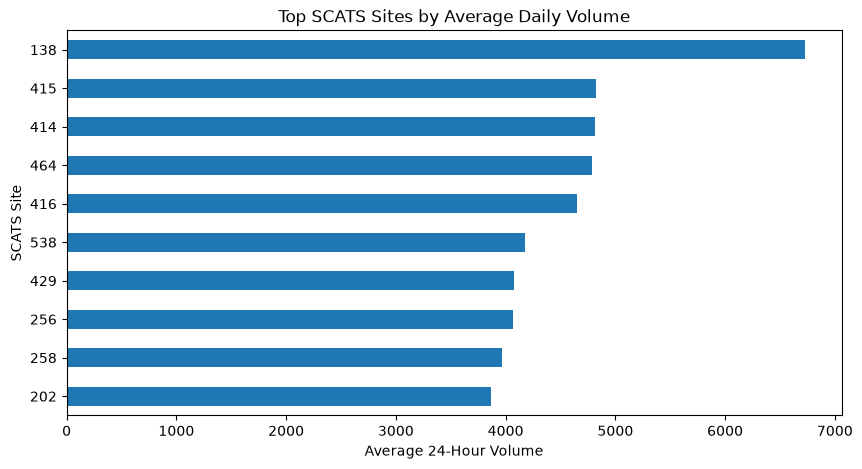

In [23]:
site_volume.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 5)
)

plt.xlabel("Average 24-Hour Volume")
plt.ylabel("SCATS Site")
plt.title("Top SCATS Sites by Average Daily Volume")

plt.show()

## Which regions have the highest traffic?

In [24]:
region_volume = (
    df.groupby("NM_REGION")["QT_VOLUME_24HOUR"]
      .mean()
      .sort_values(ascending=False)
)

region_volume

NM_REGION
WV2    1923.361014
BBN    1893.395474
SPR    1753.303322
SP2    1644.495370
CRN    1635.900806
WV1    1574.024351
DON    1543.998377
FRA    1504.585202
MEN    1195.391827
FR2     986.847561
VIC     923.354167
DIO     749.916667
VI2     583.083333
DUP     478.541667
Name: QT_VOLUME_24HOUR, dtype: float64

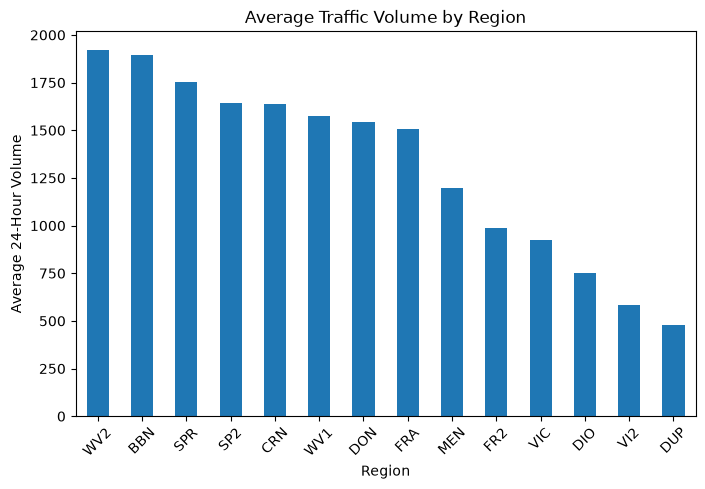

In [25]:
region_volume.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Region")
plt.ylabel("Average 24-Hour Volume")
plt.title("Average Traffic Volume by Region")

plt.xticks(rotation=45)

plt.show()

In [26]:
negative_values = (df[traffic_columns] < 0).sum()

negative_values[
    negative_values > 0
]

V00    112
V01    112
V02    112
V03    112
V04    112
      ... 
V91    111
V92    111
V93    111
V94    111
V95    111
Length: 96, dtype: int64

In [27]:
zero_percentage = (
    (df[traffic_columns] == 0).mean() * 100
).sort_values(ascending=False)

zero_percentage.head(20)

V11    75.44
V12    74.43
V10    74.34
V09    74.31
V08    73.93
V13    73.84
V14    73.23
V07    72.22
V15    72.12
V06    71.45
V05    71.20
V16    70.32
V04    70.06
V03    69.03
V17    68.82
V02    67.94
V01    66.64
V18    66.60
V00    64.79
V95    64.53
dtype: float64

## Distribution

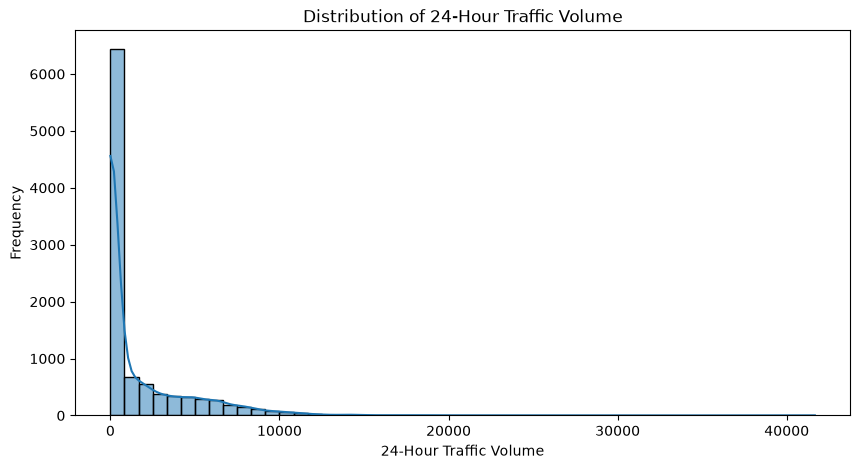

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["QT_VOLUME_24HOUR"].dropna(),
    bins=50,
    kde=True
)

plt.xlabel("24-Hour Traffic Volume")
plt.ylabel("Frequency")
plt.title("Distribution of 24-Hour Traffic Volume")

plt.show()

## Outliers

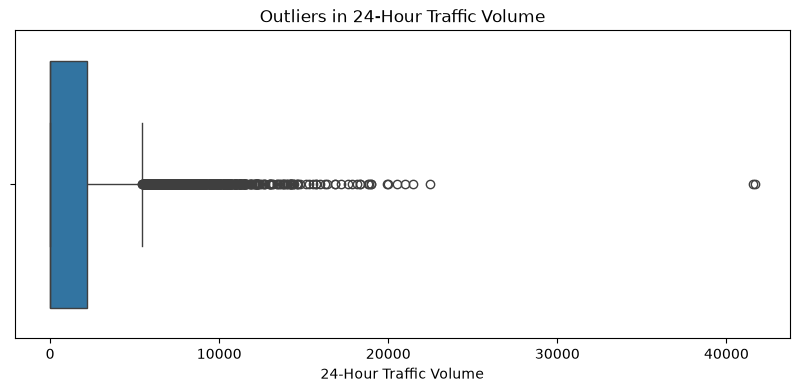

In [29]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["QT_VOLUME_24HOUR"]
)

plt.xlabel("24-Hour Traffic Volume")
plt.title("Outliers in 24-Hour Traffic Volume")

plt.show()